In [100]:
# import the basic libraries 
import  numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns 

In [101]:
## plot  style  set 
sns.set_theme(style="whitegrid",palette="muted")
plt.rcParams["figure.figsize"]=(10,6)

In [102]:
df=pd.read_csv(r"C:\Users\Acer\OneDrive\Desktop\customner churn\dataset\WA_Fn-UseC_-Telco-Customer-Churn.csv")

In [103]:
# data frame shape 
df.shape

(7043, 21)

In [104]:
# top 5 rows 
df.head(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [105]:
#column in the data 
print(f"Columnms",df.columns.tolist())

Columnms ['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [106]:
# about the data set 

# Customer Indentification 
# Customer ID - each customer's unique id 
# gender -> male/female 
# Senior citezen -> 0 or 1 
# Partner -> is they married .(yes / no)
# Dependents --> is there any dependent on home (yes/no)

#### Services
# phone service -> IS he taking the mobile connection 
#multiplelines -> more than one line 
# Internet service -> Internet type (DSL/Fibre/None)
#onlineSecurity-> (backup service)?
# device protection --> Device Insurence 
# Techsupport --> tech support plan ??
# Straming Tv --> Tv straeming 
# Streaming Moviesd _> movies streaming 

####### Related to the money 
# tenure -> from how much time he is a customer 
# Contract -> Monthly,1 year , 2 year contract 
#Paperless billing -> online bill ??
#Payment method --> how he pays 
# total charges--> How much he give till now 

#### TARGET 
# churn--> is he still a customer 

In [107]:
## Now check the target column 
print("Churn  Distribution")
print(df.Churn.value_counts())
print("In Percentage")
print(df.Churn.value_counts(normalize=True)*100) #normalize=True --> it will conveert into the propotion 

Churn  Distribution
Churn
No     5174
Yes    1869
Name: count, dtype: int64
In Percentage
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


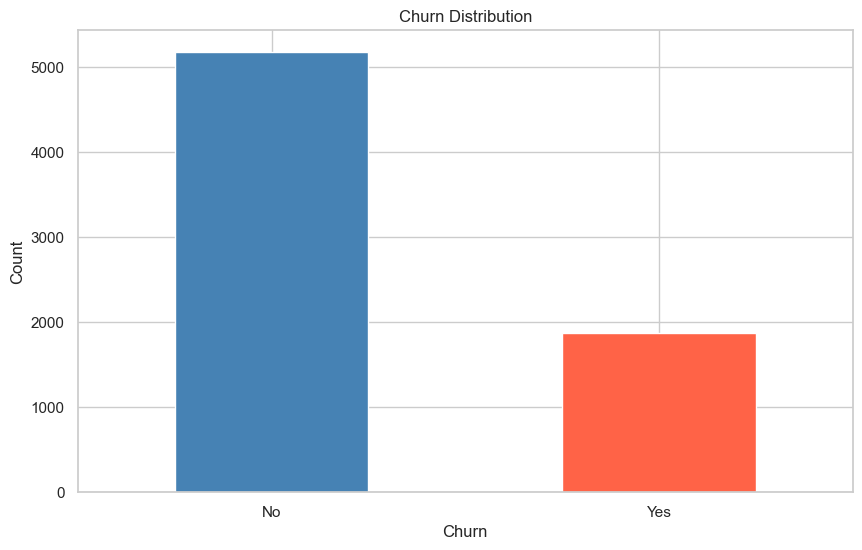

In [108]:
## Now lets see the visuals
df.Churn.value_counts().plot(kind="bar",color=["steelblue","tomato"])
plt.title("Churn Distribution")
plt.xlabel("Churn")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.show()

In [109]:
## THE above figure show that the data is imabalnce 

In [110]:
# numerical column overview 
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [111]:
# Average tenure = 32 months
# 25% customers = only  9 months
# Means — many new ciustomer goes early

In [112]:
### Checking for the miss value 
print("Missing Value")
print(df.isnull().sum())

Missing Value
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


In [113]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [114]:
print(df[df["TotalCharges"]==" "].shape[0])

11


In [115]:
df["TotalCharges"]=df["TotalCharges"].replace(" ",np.nan)
df["TotalCharges"]=pd.to_numeric(df["TotalCharges"])

In [116]:
print(df["TotalCharges"].dtype) 
print(df["TotalCharges"].isnull().sum())

float64
11


In [117]:
df["TotalCharges"]=df["TotalCharges"].fillna(0)

In [118]:
print("Missing Value:",df["TotalCharges"].isnull().sum())
print("Data Type:",df["TotalCharges"].dtype)
df["TotalCharges"].describe()

Missing Value: 0
Data Type: float64


count    7043.000000
mean     2279.734304
std      2266.794470
min         0.000000
25%       398.550000
50%      1394.550000
75%      3786.600000
max      8684.800000
Name: TotalCharges, dtype: float64

In [119]:
## EDA 

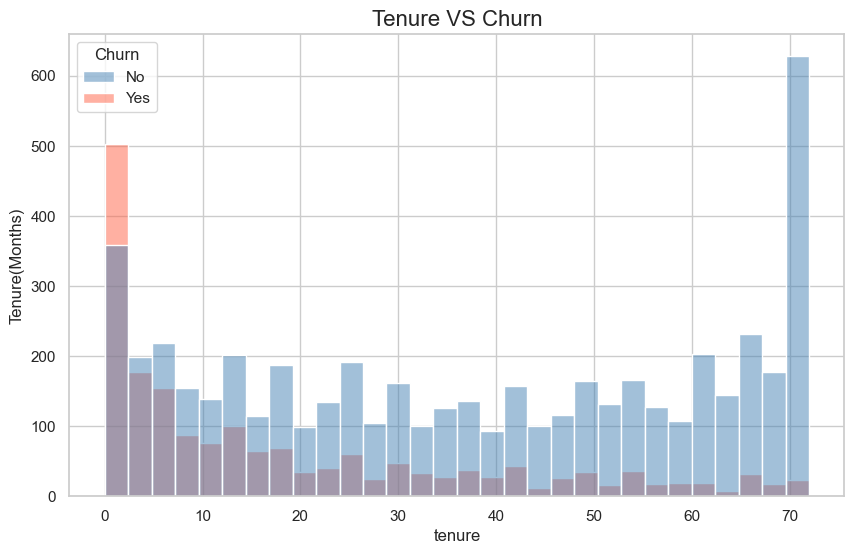

In [120]:
# CHURN VS TENURE - how much time after the customer leaves 
plt.figure(figsize=(10,6))
sns.histplot(data=df,x="tenure",hue="Churn",bins=30,palette=["steelblue","tomato"])
plt.title("Tenure VS Churn",fontsize=16)
plt.ylabel("Tenure(Months)",fontsize=12)
plt.show()

In [121]:
## INSIGHT -> if the persomn is a customer for the 20 month then it wil be permanent 

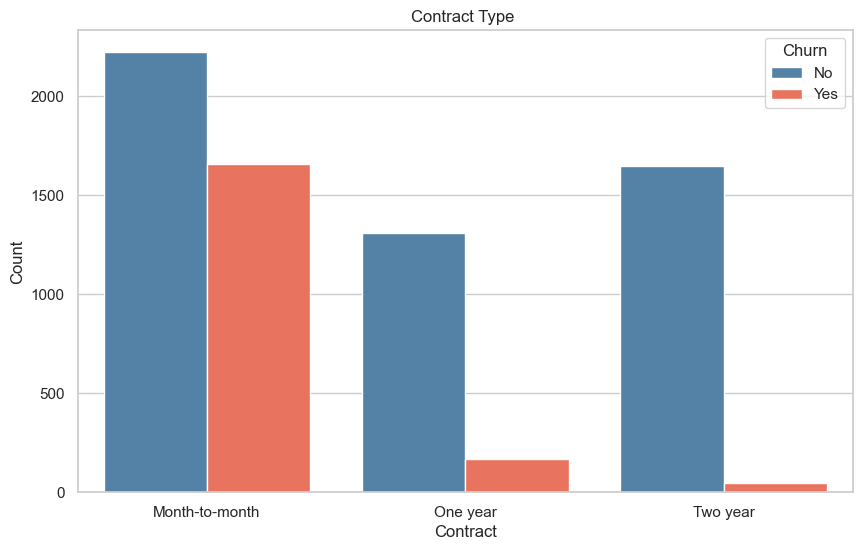

In [122]:
### Contacvt type 
plt.figure(figsize=(10,6))
sns.countplot(data=df,x="Contract",hue="Churn",palette=["steelblue","tomato"])
plt.title("Contract Type ",fontsize=12)
plt.ylabel("Count",fontsize=12)
plt.show()

In [123]:
## month to month  contact has high churn rate 

C:\Users\Acer\AppData\Local\Temp\ipykernel_6664\1438087795.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df,x="Churn",y="MonthlyCharges",palette=["steelblue","tomato"])


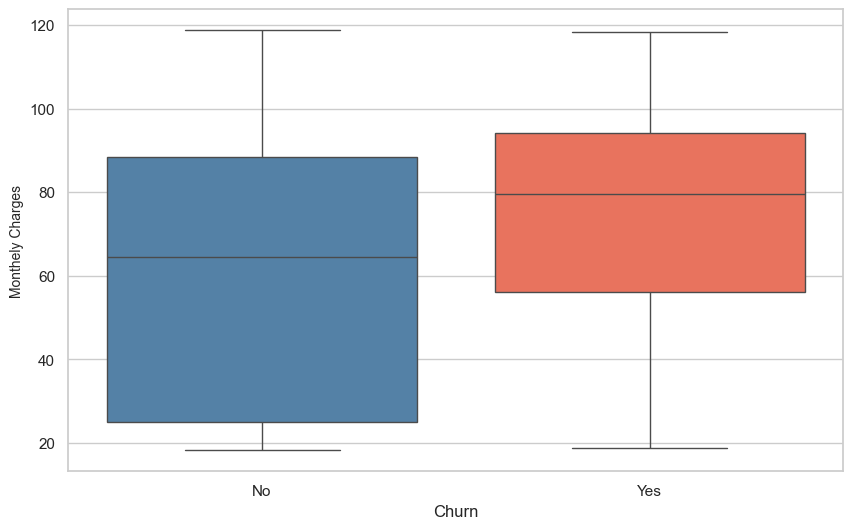

In [124]:
plt.figure(figsize=(10,6))
sns.boxplot(data=df,x="Churn",y="MonthlyCharges",palette=["steelblue","tomato"])
plt.xlabel("Churn",fontsize=12)
plt.ylabel("Monthely Charges",fontsize=10)
plt.show()

In [125]:
## if the monthely cahrgees is more then the customer leaves

C:\Users\Acer\AppData\Local\Temp\ipykernel_6664\345470245.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Churn', y='TotalCharges',


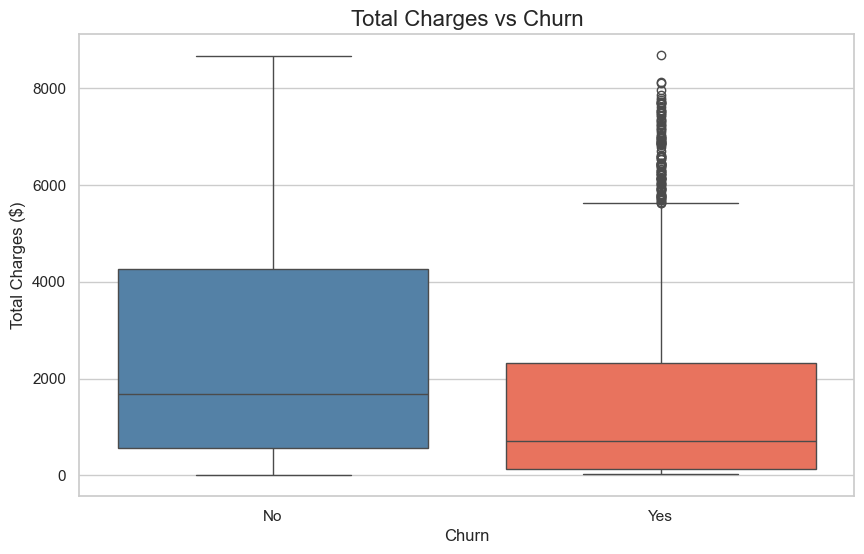

In [126]:
# 1. TotalCharges vs Churn
plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='Churn', y='TotalCharges',
            palette=['steelblue','tomato'])
plt.title('Total Charges vs Churn', fontsize=16)
plt.xlabel('Churn')
plt.ylabel('Total Charges ($)')
plt.show()

In [127]:
# churn customer has the loer total charges

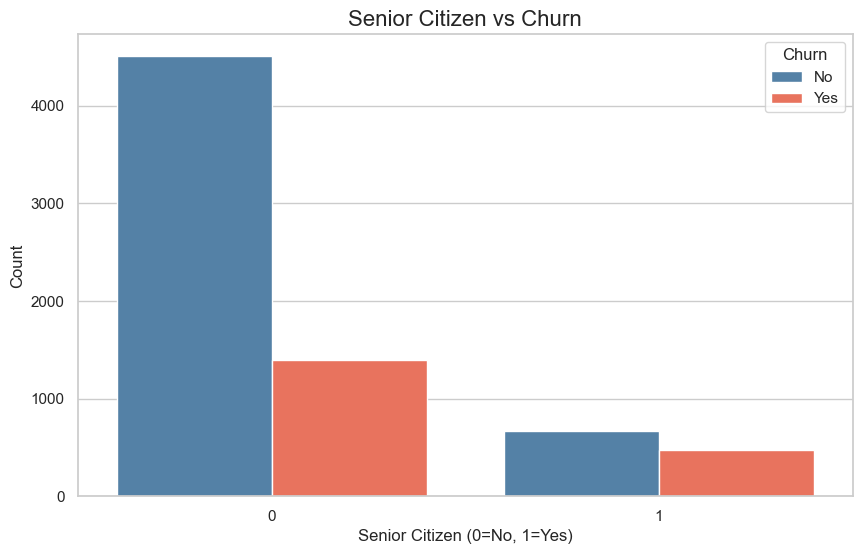

In [128]:
# 2. Senior Citizen vs Churn

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='SeniorCitizen', hue='Churn',
              palette=['steelblue','tomato'])
plt.title('Senior Citizen vs Churn', fontsize=16)
plt.xlabel('Senior Citizen (0=No, 1=Yes)')
plt.ylabel('Count')
plt.show()

In [129]:
## senior citizen has low rate.

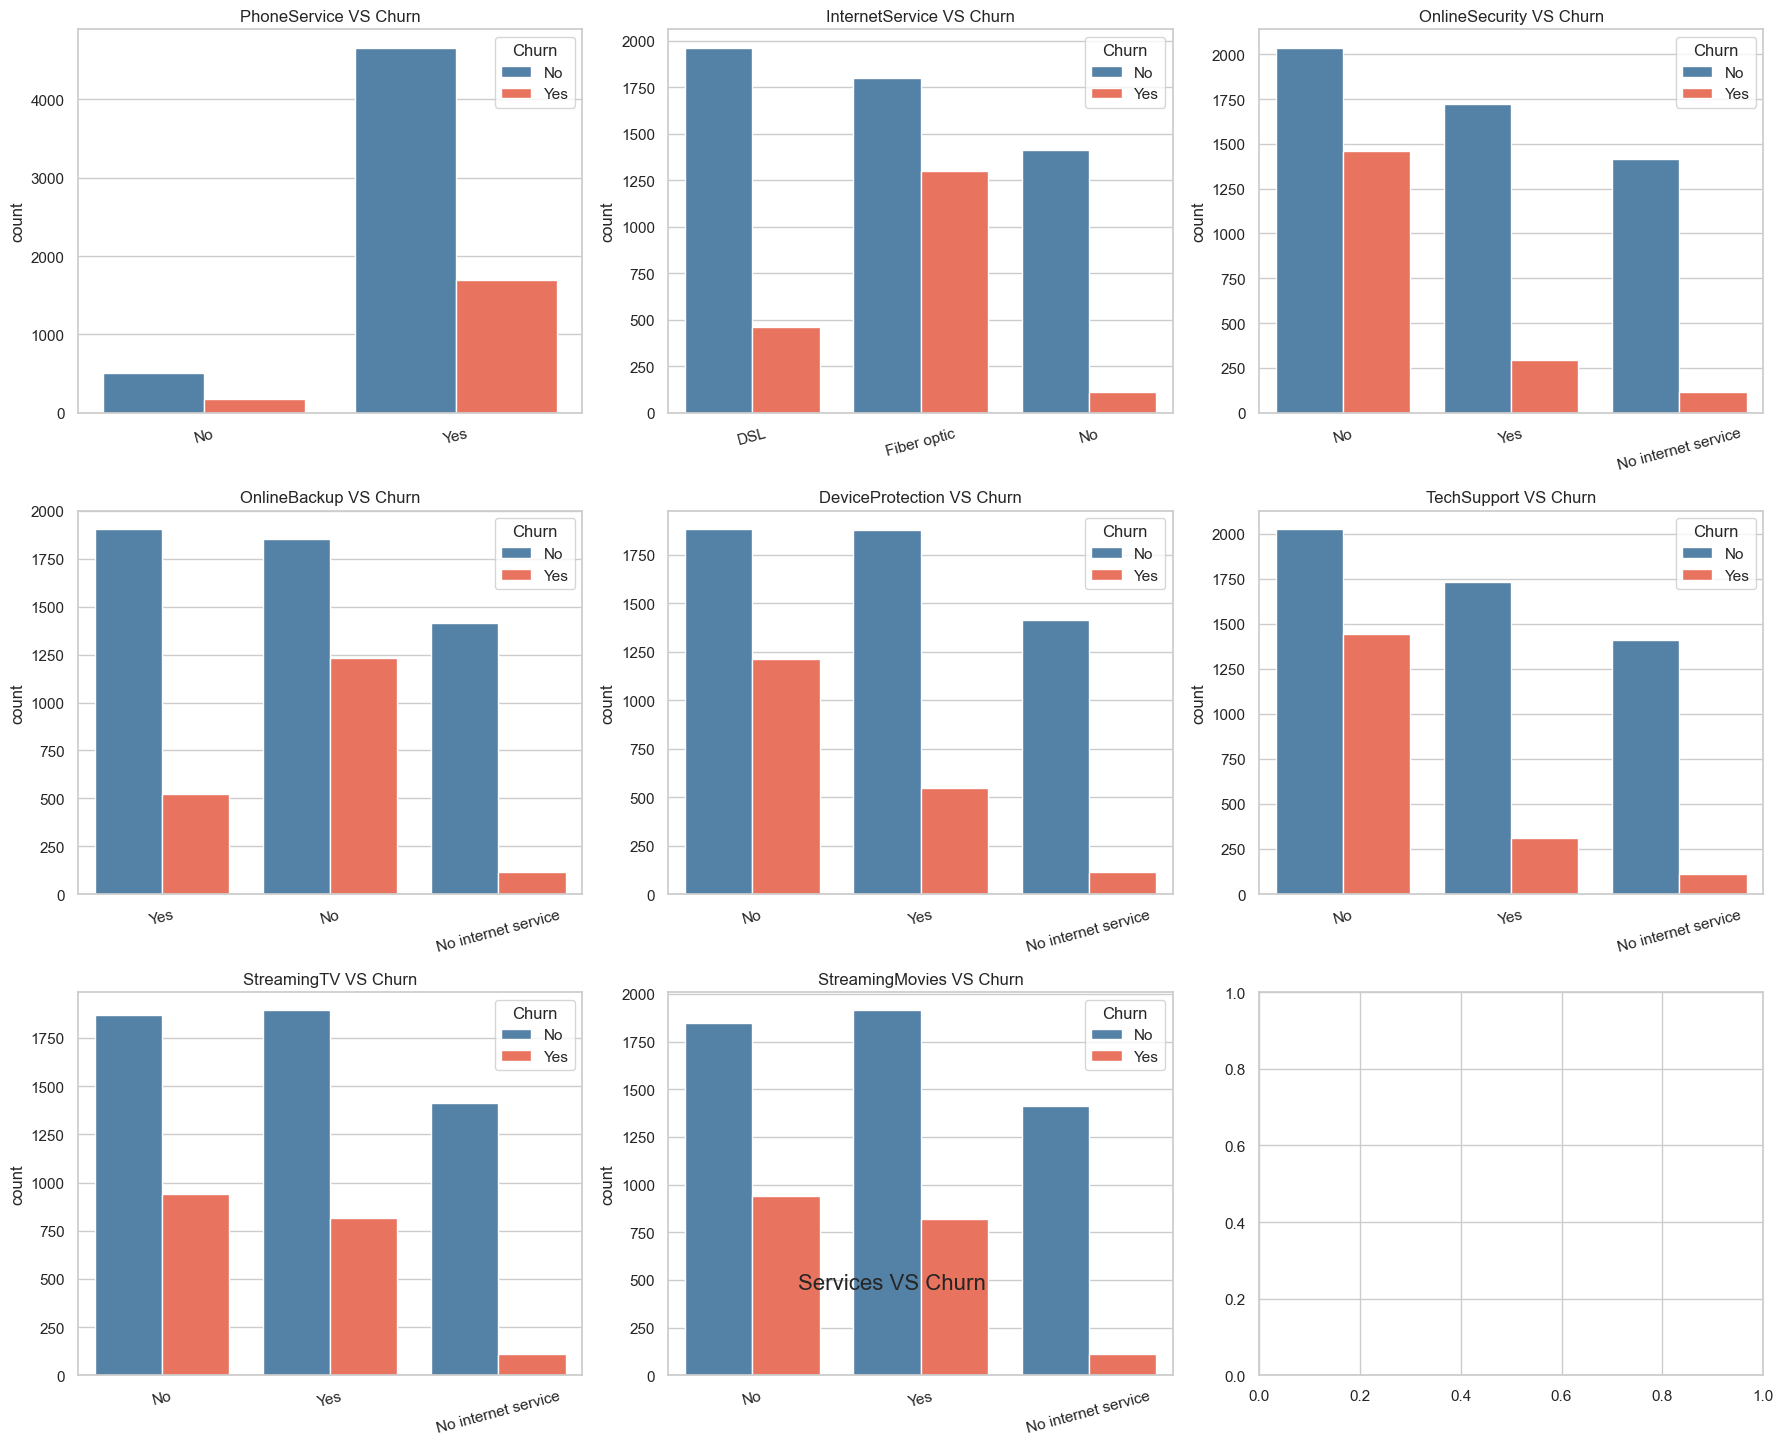

In [130]:
services = ['PhoneService', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies']
fig,axes=plt.subplots(3,3,figsize=(18,15))
axes=axes.flatten()
for i,col in enumerate(services):
    sns.countplot(data=df,x=col,hue="Churn",palette=["steelblue","tomato"],ax=axes[i])
    axes[i].set_title(f"{col} VS Churn",fontsize=12)
    axes[i].set_xlabel("")
    axes[i].tick_params(axis="x",rotation=15)
plt.suptitle("Services VS Churn",fontsize=16,y=0.12)
plt.tight_layout()
plt.show()

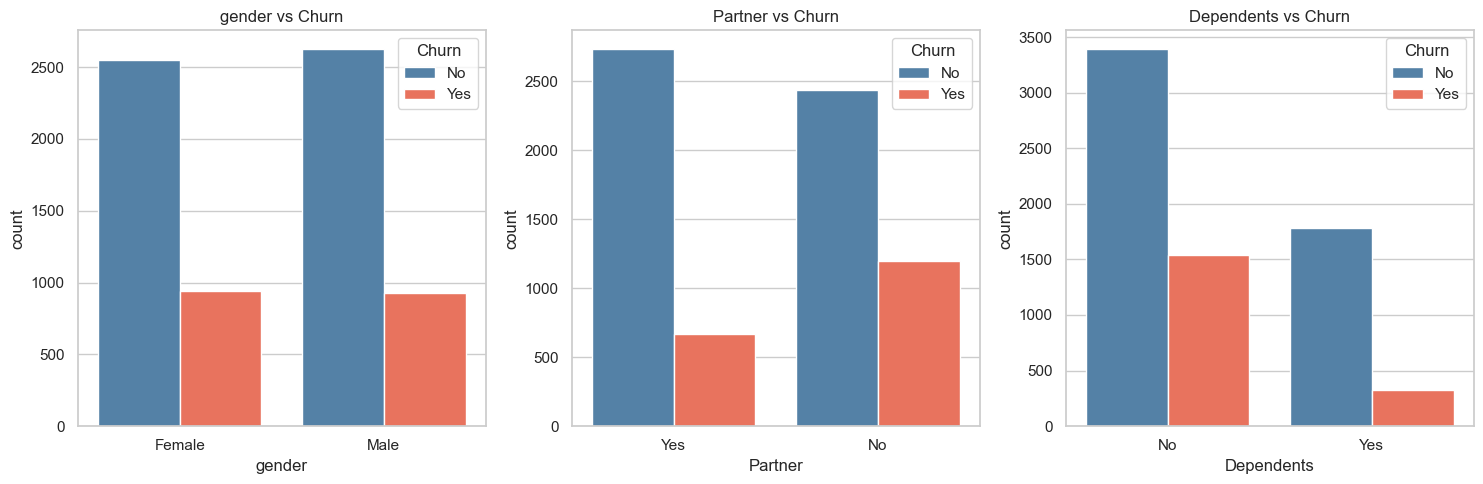

In [131]:
personal = ['gender', 'Partner', 'Dependents']
fig,axes=plt.subplots(1,3,figsize=(15,5))
for i ,col in enumerate(personal):
    sns.countplot(data=df,x=col,hue="Churn",palette=["steelblue","tomato"],ax=axes[i])
    axes[i].set_title(f"{col} vs Churn",fontsize=12)
plt.tight_layout()
plt.show()

In [132]:
## gender has the same rate in churn so it is not benifit in the data

In [133]:
print(df.select_dtypes(include="object").columns.tolist())

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'Churn']


In [134]:
df =df.drop("customerID",axis=1)
print("CustomerID Dropeed",df.shape)

CustomerID Dropeed (7043, 20)


In [135]:
# step2 label encoding 
label_cols = ['gender', 'Partner', 'Dependents', 
              'PhoneService', 'PaperlessBilling', 'Churn']
replace_map={"Yes":1,"No":0,"Male":1,"Female":0}
for col in label_cols:
    df[col]=df[col].map(replace_map)
print("Label Encodeing Done")
print(df[label_cols].head())

Label Encodeing Done
   gender  Partner  Dependents  PhoneService  PaperlessBilling  Churn
0       0        1           0             0                 1      0
1       1        0           0             1                 0      0
2       1        0           0             1                 1      1
3       1        0           0             0                 0      0
4       0        0           0             1                 1      1


In [136]:
ohe_cols = ['MultipleLines', 'InternetService', 'OnlineSecurity',
            'OnlineBackup', 'DeviceProtection', 'TechSupport',
            'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']
df = pd.get_dummies(df, columns=ohe_cols, drop_first=True)

print("One Hot Encoding done!")
print("New shape:", df.shape)

One Hot Encoding done!
New shape: (7043, 31)


In [137]:
# scaling the data
from sklearn.preprocessing import StandardScaler
scale_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler()
df[scale_cols] = scaler.fit_transform(df[scale_cols])

print("Scaling done!")
print(df[scale_cols].describe().round(2))

Scaling done!
        tenure  MonthlyCharges  TotalCharges
count  7043.00         7043.00       7043.00
mean     -0.00           -0.00         -0.00
std       1.00            1.00          1.00
min      -1.32           -1.55         -1.01
25%      -0.95           -0.97         -0.83
50%      -0.14            0.19         -0.39
75%       0.92            0.83          0.66
max       1.61            1.79          2.83


In [138]:
X=df.drop("Churn",axis=1)
y=df.Churn

In [139]:
print("X shape",X.shape)
print("Y shape",y.shape)
print(y.value_counts())

X shape (7043, 30)
Y shape (7043,)
Churn
0    5174
1    1869
Name: count, dtype: int64


In [140]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print("Train Size :",X_train.shape)
print("Test Shape: ",X_test.shape)

Train Size : (5634, 30)
Test Shape:  (1409, 30)


In [141]:
# balance the  imabalane model by weights 
from sklearn.utils.class_weight import compute_class_weight
import numpy as np 
class_weight=compute_class_weight(class_weight="balanced",classes=np.unique(y_train),y=y_train)
class_weight_dict=dict(enumerate(class_weight))
print("Class Weight",class_weight_dict)

Class Weight {0: np.float64(0.6805991785455424), 1: np.float64(1.8842809364548494)}


In [142]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers 
model=keras.Sequential([layers.Dense(64,activation="relu",input_shape=(30,)),
                        layers.Dropout(0.3),
                        layers.Dense(32,activation="relu"),
                        layers.Dropout(0.3),
                        layers.Dense(1,activation="sigmoid")
                       ]
                      )

C:\Users\Acer\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [143]:
model.compile(loss="binary_crossentropy",optimizer="adam",metrics=["accuracy"])
model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                      │ (None, 64)                  │           1,984 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 4,097 (16.00 KB)

 Trainable params: 4,097 (16.00 KB)

 Non-trainable params: 0 (0.00 B)

In [144]:
history=model.fit(X_train,y_train,epochs=50,batch_size=32,validation_split=0.2,class_weight=class_weight_dict,verbose=1)

Epoch 1/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.7118 - loss: 0.5677 - val_accuracy: 0.7143 - val_loss: 0.5624
Epoch 2/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7504 - loss: 0.5121 - val_accuracy: 0.7187 - val_loss: 0.5502
Epoch 3/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7495 - loss: 0.5020 - val_accuracy: 0.7267 - val_loss: 0.5202
Epoch 4/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7519 - loss: 0.4960 - val_accuracy: 0.7223 - val_loss: 0.5253
Epoch 5/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7544 - loss: 0.4956 - val_accuracy: 0.7240 - val_loss: 0.5218
Epoch 6/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7579 - loss: 0.4869 - val_accuracy: 0.7400 - val_loss: 0.4910
Epoch 7/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7582 - loss: 0.4849 - val_accuracy: 0.7294 - val_loss: 0.4989
Epoch 8/50
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7602 - loss: 0.4784 - val_accuracy: 0

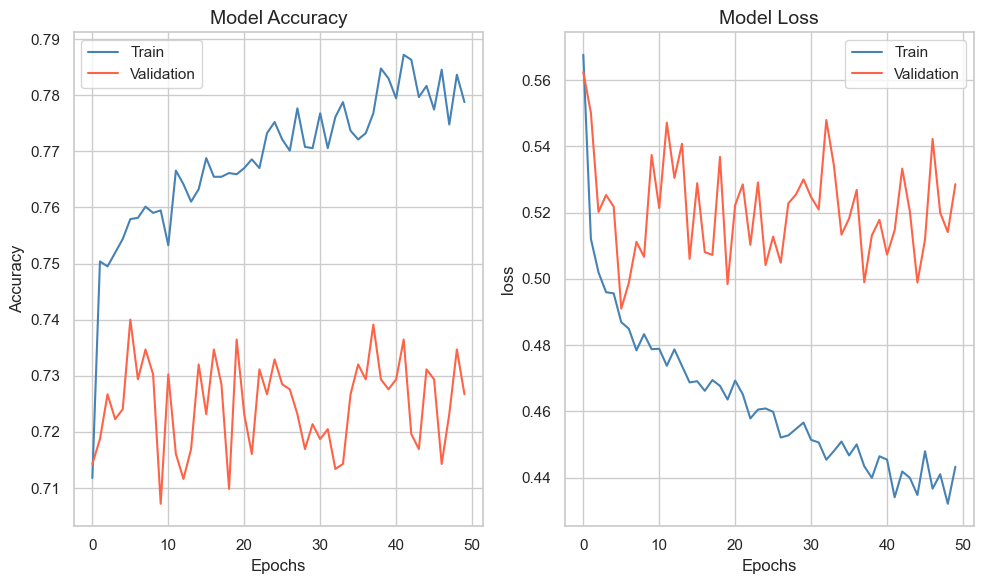

In [145]:
fig,axes=plt.subplots(1,2,figsize=(10,6))
# Accuracy Plot 
axes[0].plot(history.history["accuracy"],label="Train",color="steelblue")
axes[0].plot(history.history["val_accuracy"],label="Validation",color="tomato")
axes[0].set_title("Model Accuracy",fontsize=14)
axes[0].set_xlabel("Epochs")
axes[0].set_ylabel("Accuracy")
axes[0].legend()

#loss plot 
axes[1].plot(history.history["loss"],label="Train",color="steelblue")
axes[1].plot(history.history["val_loss"],label="Validation",color="tomato")
axes[1].set_title("Model Loss",fontsize=14)
axes[1].set_xlabel("Epochs")
axes[1].set_ylabel("loss")
axes[1].legend()

plt.tight_layout()
plt.show()

In [146]:
# Lets Fix the model Overfitting .
from tensorflow.keras.callbacks import EarlyStopping
model2=keras.Sequential([
    layers.Dense(32,activation="relu",input_shape=(30,)),
    layers.Dropout(0.3),
    layers.Dense(16,activation="relu"),
    layers.Dropout(0.4),
    layers.Dense(1,activation="sigmoid")
])

model2.compile(optimizer="adam",loss="binary_crossentropy",metrics=["accuracy"])
# Early stopping -> JAb improve na ho to stop 
early_stop=EarlyStopping(monitor="val_loss",patience=5,restore_best_weights=True)

history2 = model2.fit(X_train, y_train,epochs=100,batch_size=32,validation_split=0.2,
    class_weight=class_weight_dict,
    callbacks=[early_stop],
    verbose=1
)

C:\Users\Acer\miniconda3\Lib\site-packages\keras\src\layers\core\dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.6716 - loss: 0.6266 - val_accuracy: 0.7081 - val_loss: 0.5343
Epoch 2/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7113 - loss: 0.5604 - val_accuracy: 0.7196 - val_loss: 0.5196
Epoch 3/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7240 - loss: 0.5372 - val_accuracy: 0.7187 - val_loss: 0.5350
Epoch 4/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7344 - loss: 0.5245 - val_accuracy: 0.7223 - val_loss: 0.5281
Epoch 5/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7369 - loss: 0.5191 - val_accuracy: 0.7187 - val_loss: 0.5173
Epoch 6/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7453 - loss: 0.5172 - val_accuracy: 0.7107 - val_loss: 0.5456
Epoch 7/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7455 - loss: 0.5155 - val_accuracy: 0.7223 - val_loss: 0.5277
Epoch 8/100
141/141 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7437 - loss: 0.5069 - val_acc

In [147]:
loss, accuracy = model2.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {accuracy*100:.2f}%")
print(f"Test Loss: {loss:.4f}")

Test Accuracy: 74.59%
Test Loss: 0.4895


45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step
              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



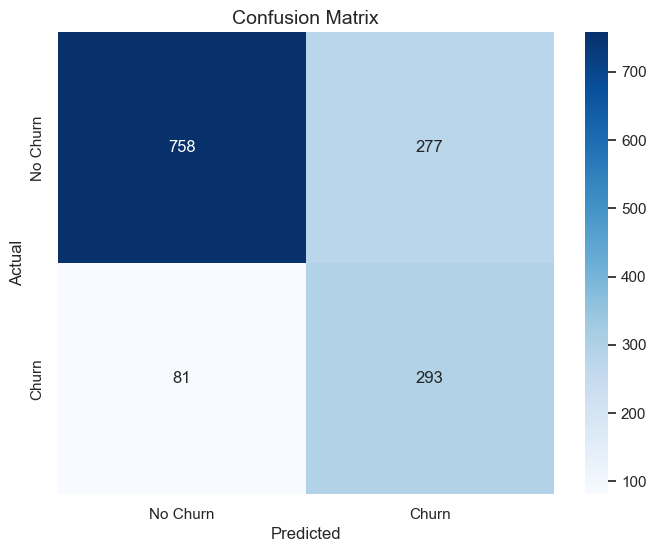

In [148]:

from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns

# Predictions lo
y_pred = (model2.predict(X_test) > 0.5).astype(int)

# Classification Report
print(classification_report(y_test, y_pred, 
      target_names=['No Churn', 'Churn']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', 
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()


In [149]:
from sklearn.metrics import f1_score
import numpy as np
y_prob = model2.predict(X_test) # we take the raw probs for the cutoff
thresholds=np.arange(0.1,0.9,0.05)# np.arrange(start,stop,step)
best_threshold=0.5 # till now the best cutoff
best_f1=0 # till now the best f1 score 
result=[] # store the all  the result 
for thresh in thresholds:
    y_pred_thresh=(y_prob>thresh).astype(int) 
    #y_prob>thresh =[True,False,True] --> .astype(int) --> [0,1,0]---> 0.82>0.5 --> 1 --> (churn)
    f1=f1_score(y_test,y_pred_thresh)
    # on this threshold caluclate the f1 score -> Actual vs predicted Compare 
    result.append({"threshold":thresh,"f1":f1}) #  store the all result 
    if f1>best_f1: # it the new threshold is better then update the best
        best_f1=f1
        best_threshold=thresh
print(f"Best Threshhld:{best_threshold:.2f}")
print(f"Best F1 score :{best_f1:.4f}")

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step
Best Threshhld:0.60
Best F1 score :0.6287


In [150]:
# Keras threshold tuning 

Classification Report               precision    recall  f1-score   support

    No Churn       0.88      0.80      0.84      1035
       Churn       0.57      0.71      0.63       374

    accuracy                           0.78      1409
   macro avg       0.72      0.76      0.74      1409
weighted avg       0.80      0.78      0.79      1409



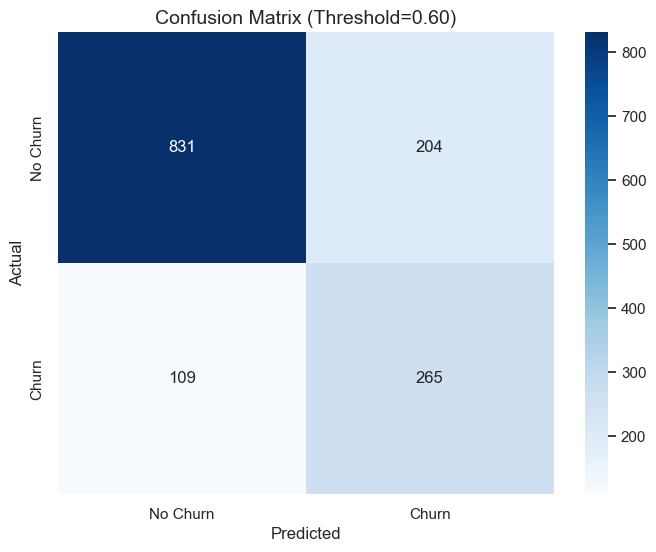

In [151]:
y_pred_best=(y_prob>best_threshold).astype(int)
print("Classification Report",classification_report(y_test,y_pred_best,target_names=["No Churn","Churn"]))
# confusion matrix
cm=confusion_matrix(y_test,y_pred_best)
cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d',
            cmap='Blues',
            xticklabels=['No Churn', 'Churn'],
            yticklabels=['No Churn', 'Churn'])
plt.title('Confusion Matrix (Threshold=0.60)', fontsize=14)
plt.ylabel('Actual')
plt.xlabel('Predicted')
plt.show()

In [152]:
# Before the Recall is 0.75 and the f1 is 0.61
# No  the recall si 0.70 and the f1 is 0.62
# Now the model is confident 

In [153]:
#precision --> how muvh time the model say the customer says it wil leave and it is right 
# recall --> how much  the model predict right  ( total customer that will go ) how much model catch them
## F1 score -> precision and recall summary 

In [154]:
## the data is tabular so i  think i should apply the xgboost for better result 

In [155]:
!pip install xgboost 

In [156]:
from xgboost import XGBClassifier

In [157]:
X_gb_model=XGBClassifier(n_estimator=500 ,# 200 trees make ,
                         learning_rate=0.05,max_depth=4, # trees depth 
                         subsample=0.8,# 80 % data each tree
                         colsample_bytree=0.8,#80% feature har tree ko 
                         scale_pos_weight=2.7 # Imbalance data fix 
                         ,random_state=42,eval_metric="logloss")
X_gb_model.fit(X_train,y_train,eval_set=[(X_test,y_test)],verbose=False)
print("XGB TRAINED")

C:\Users\Acer\miniconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [21:52:01] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "n_estimator" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGB TRAINED


In [158]:
y_pred_xgb=X_gb_model.predict(X_test)
print("Xgboost Classification Report")
print(classification_report(y_test,y_pred_xgb,target_names=["No Churn","Churn"]))

Xgboost Classification Report
              precision    recall  f1-score   support

    No Churn       0.91      0.73      0.81      1035
       Churn       0.52      0.80      0.63       374

    accuracy                           0.75      1409
   macro avg       0.72      0.77      0.72      1409
weighted avg       0.81      0.75      0.76      1409



In [159]:
#Xgboost Threshold Tuning 
y_prob_xgb=X_gb_model.predict_proba(X_test)[:,1]
threshold=np.arange(0.1,0.9,0.05)
best_threshold_xgb=0.5
best_f1_xgb=0
for thresh in threshold:
    y_predict_thresh=(y_prob_xgb>thresh).astype(int)
    f1=f1_score(y_test,y_predict_thresh)
    if f1>best_f1_xgb:
        best_f1_xgb=f1
        best_threshold_xgb=thresh
print(f"Best Threshold:{best_threshold_xgb:.2f}")
print(f"best f1 score:{best_f1_xgb:.4f}")
    

Best Threshold:0.50
best f1 score:0.6324


In [160]:
y_pred_final = (y_prob_xgb > 0.60).astype(int)

print("Final XGBoost Report:")
print(classification_report(y_test, y_pred_final,
      target_names=['No Churn', 'Churn']))

Final XGBoost Report:
              precision    recall  f1-score   support

    No Churn       0.88      0.81      0.84      1035
       Churn       0.57      0.69      0.62       374

    accuracy                           0.78      1409
   macro avg       0.72      0.75      0.73      1409
weighted avg       0.80      0.78      0.78      1409



In [161]:
!pip install imbalanced-learn

In [162]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)
X_train_smote,y_train_smote=smote.fit_resample(X_train,y_train)
#fit _resample==it do two work together 
#1. fit --> see the data and analyze the pattern 
#2. resample--> fake samples bnade 
print("Before")
print(f"No churn: {sum(y_train==0)}")
print(f"Churn: {sum(y_train==1)}")

print("After Appyuing the SMOTE")
print(f"No Churn : {sum(y_train_smote==0)}")
print(f"No Churn : {sum(y_train_smote==1)}")


Before
No churn: 4139
Churn: 1495
After Appyuing the SMOTE
No Churn : 4139
No Churn : 4139


In [163]:
## NOW  SMOTE + XGBOOST 
X_gb_smote=xgb_smote = XGBClassifier(
    n_estimators=500,
    learning_rate=0.01,
    max_depth=3,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss'
)


In [164]:
xgb_smote.fit(
    X_train_smote, y_train_smote,
    eval_set=[(X_test, y_test)],
    verbose=False
)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,0.8
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes f

In [165]:
y_pred_smote = xgb_smote.predict(X_test)

In [166]:
print(classification_report(y_test, y_pred_smote,
      target_names=['No Churn', 'Churn']))

              precision    recall  f1-score   support

    No Churn       0.90      0.73      0.81      1035
       Churn       0.51      0.78      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [167]:
## Smote  reduce the precison 
# but stll the Xgboost is best with the weights

In [169]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges',
       'Churn', 'MultipleLines_No phone service', 'MultipleLines_Yes',
       'InternetService_Fiber optic', 'InternetService_No',
       'OnlineSecurity_No internet service', 'OnlineSecurity_Yes',
       'OnlineBackup_No internet service', 'OnlineBackup_Yes',
       'DeviceProtection_No internet service', 'DeviceProtection_Yes',
       'TechSupport_No internet service', 'TechSupport_Yes',
       'StreamingTV_No internet service', 'StreamingTV_Yes',
       'StreamingMovies_No internet service', 'StreamingMovies_Yes',
       'Contract_One year', 'Contract_Two year',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype='object')

In [178]:
# Feature Reengineering 

In [174]:
df['TotalServices'] = ( 
    df['PhoneService'] +
    df['OnlineSecurity_Yes'] +
    df['OnlineBackup_Yes'] +
    df['DeviceProtection_Yes'] +
    df['TechSupport_Yes'] +
    df['StreamingTV_Yes'] +
    df['StreamingMovies_Yes']
)
# Feature 2: Average Revenue Per Tenure # if the customer is new and  revenue is more then  he will leave 
df["AvgRevenuPerTime"]=df["MonthlyCharges"]/(df["tenure"]+1) # tenure +1  add kiya if tenure 0 ho gya to  error aa jayega 

# Feature 3  \
df["High Risk"]=(
    (df["tenure"]<-0.5) # Naya customer (sacled)
    &(df["MonthlyCharges"]>0.5) # High charges(scaled)
).astype(int)


In [177]:
print(df[["TotalServices","AvgRevenuPerTime","High Risk"]].describe())

       TotalServices  AvgRevenuPerTime    High Risk
count    7043.000000       7043.000000  7043.000000
mean        2.941076         -0.247663     0.102939
std         1.843899         17.541619     0.303901
min         0.000000       -199.957699     0.000000
25%         1.000000         -0.770368     0.000000
50%         3.000000          0.270386     0.000000
75%         4.000000          0.965458     0.000000
max         7.000000        178.202508     1.000000


In [188]:
new_col=["TotalServices","AvgRevenuPerTime","High Risk"]
df[new_col]=scaler.fit_transform(df[new_col])

In [189]:
X_new=df.drop("Churn",axis=1)
y_new=df["Churn"]

X_train_new,X_test_new,y_train_new,y_test_new=train_test_split(X_new,y_new,test_size=0.2,random_state=42,stratify=y_new)

In [192]:
# Appluying the smote 
X_train_new_smote,y_train_new_smote=smote.fit_resample(X_train_new,y_train_new)
print("Train Shape : ",X_train_new_smote.shape)
print("Test Shape : ",X_test_new.shape)

Train Shape :  (8278, 33)
Test Shape :  (1409, 33)


In [201]:
#model make 
X_gb2=XGBClassifier(n_estimators=500,
                    learning_rate=0.01,
                    max_depth=4,
                    subsample=0.8,
                    colsample_bytree=0.8,
                    random_state=42,
                    eval_metric="logloss"
                   )
X_gb2.fit(X_train_new_smote,y_train_new_smote,eval_set=[(X_test_new,y_test_new)],verbose=False)
y_pred_final=X_gb2.predict(X_test_new)
print(classification_report(y_test_new,y_pred_final,target_names=["No churn","Churn"]))
    

              precision    recall  f1-score   support

    No churn       0.90      0.74      0.81      1035
       Churn       0.52      0.76      0.62       374

    accuracy                           0.75      1409
   macro avg       0.71      0.75      0.71      1409
weighted avg       0.80      0.75      0.76      1409



In [202]:
# still it is not better then previoius model 


In [203]:
## Modle saving 
import pickle
# pickle : Python object ko file ne save karo Jase ml model , scaler binary format me save hote hain 
import json  #dictionary ko file mein save karo human readable format me (.josm) me
import os 
os.makedirs('../models',exist_ok=True)
# makedirs -> folder bnao 
#".../models" -> ek level upar jao model folder bnao 
# exist_ok=True -> Agar phele se hai --> error mat do 

#model save
with open("../models/churn_model.pkl","wb")as f:
    pickle.dump(X_gb_smote,f)
    
    #open-> file open 
    #wb --> w--> write ,b--> binary format 
    #with -> if the work is done then close the file
    #pickle.dump-> Model ko file me dalo

with open("../models/scaler.pkl",'wb')as f:
    pickle.dump(scaler,f)

with open("../models/threshold.json","w")as f:
    json.dump({"threshold":0.3},f)


    